# E-Commerce Sales Data Visualization and Insights

This project focuses on visualizing E-Commerce sales data using Python visualization libraries. The objective is to transform raw transactional data into meaningful visual insights that support business decision-making.

# Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load Dataset

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/Data Set/Project Dataset 4.xlsx')

# Dataset Overview

In [ ]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [ ]:
df.shape

(1200, 14)

In [ ]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


# Check Missing Values

In [ ]:
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


# Handle Missing Values

In [ ]:
df['CouponCode'] = df['CouponCode'].fillna('Not use the Coupon')

# Check Duplicate Records

In [ ]:
df.duplicated().sum()

np.int64(0)

# Verify Dataset is Clean

In [ ]:
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


# Visualization 1 - Most Sold Products

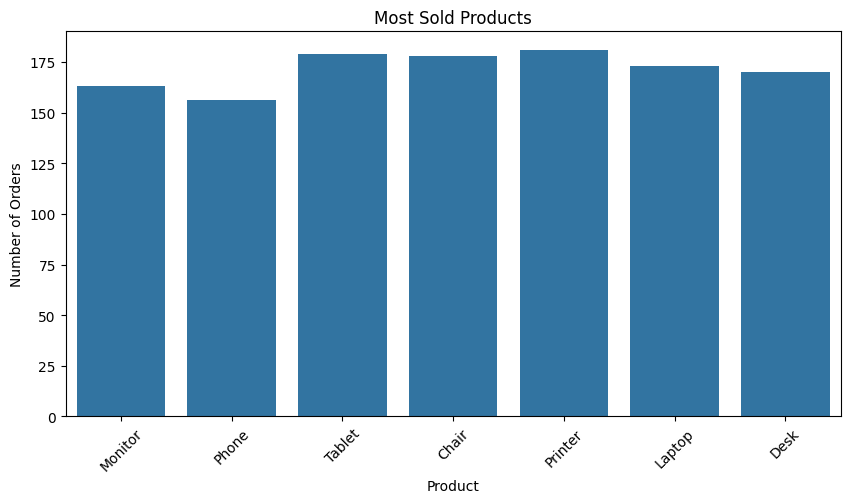

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='Product'
)

plt.title('Most Sold Products')
plt.xlabel('Product')
plt.ylabel('Number of Orders')

plt.xticks(rotation=45)

plt.show()

# Visualization 2 - Payment Method Distribution

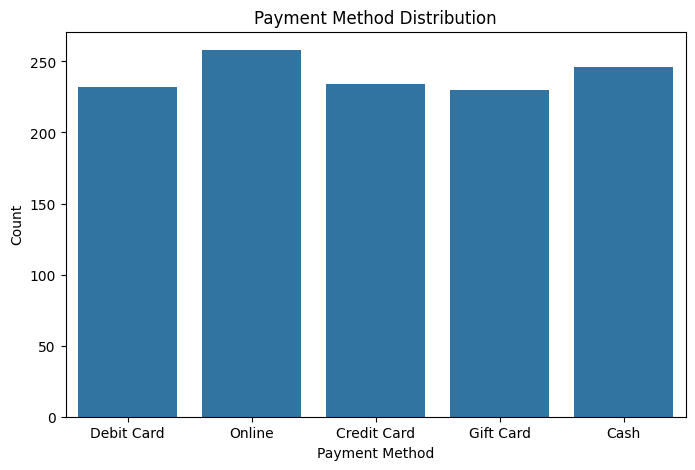

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='PaymentMethod'
)

plt.title('Payment Method Distribution')
plt.xlabel('Payment Method')
plt.ylabel('Count')

plt.show()

# Visualization 3 - Order Status Pie Chart

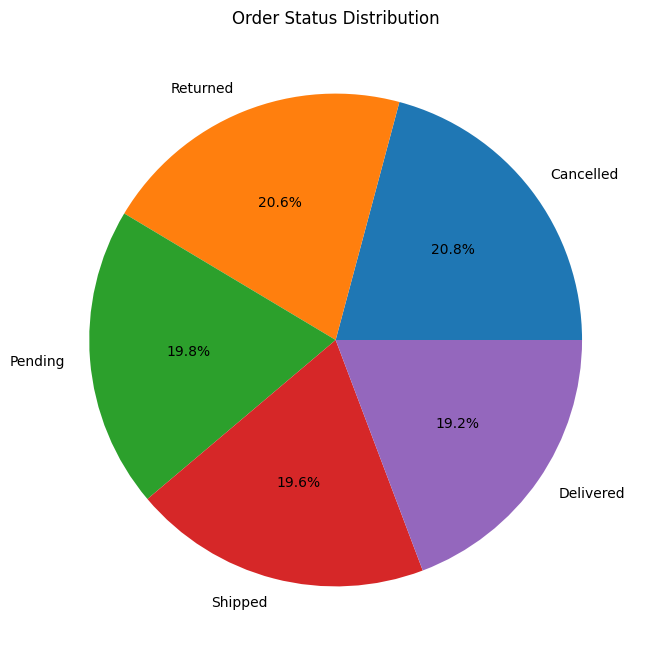

In [ ]:
status_counts = df['OrderStatus'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%'
)

plt.title('Order Status Distribution')

plt.show()

# Visualization 4 - Referral Source Distribution

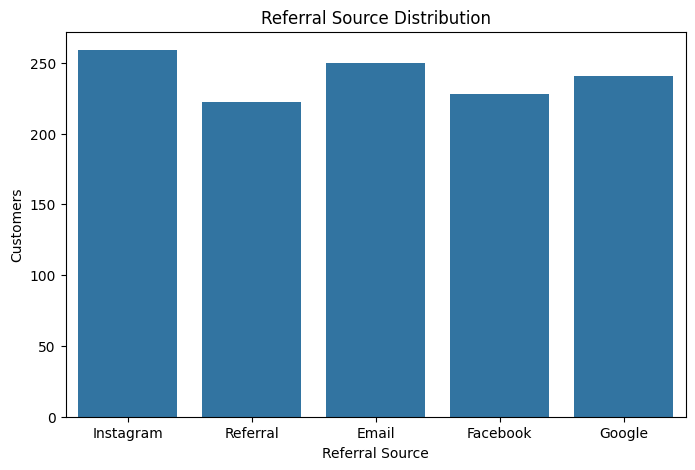

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='ReferralSource'
)

plt.title('Referral Source Distribution')
plt.xlabel('Referral Source')
plt.ylabel('Customers')

plt.show()

# Visualization 5 - Monthly Sales Trend

Convert Date

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

Calculate Monthly Sales

In [ ]:
monthly_sales = df.groupby('Month')['TotalPrice'].sum()

Line Chart

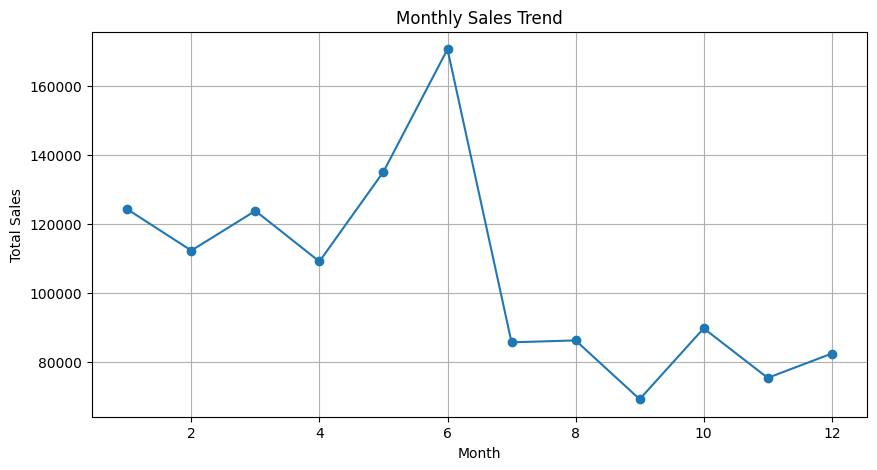

In [ ]:
monthly_sales = df.groupby('Month')['TotalPrice'].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot(
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.grid(True)

plt.show()

# Visualization 6 - Revenue by Product

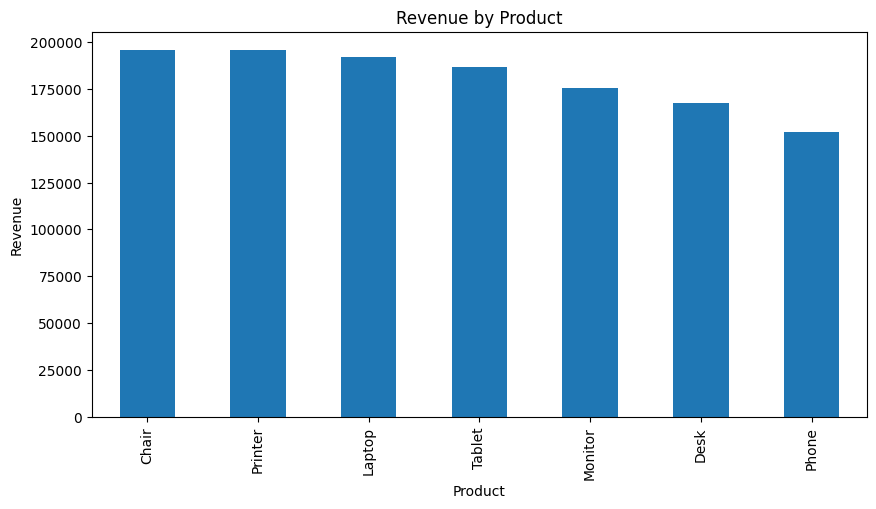

In [ ]:
revenue = df.groupby('Product')['TotalPrice'].sum()

plt.figure(figsize=(10,5))

revenue.sort_values(
    ascending=False
).plot(kind='bar')

plt.title('Revenue by Product')
plt.xlabel('Product')
plt.ylabel('Revenue')

plt.show()

# Visualization 7 - Total Price Distribution

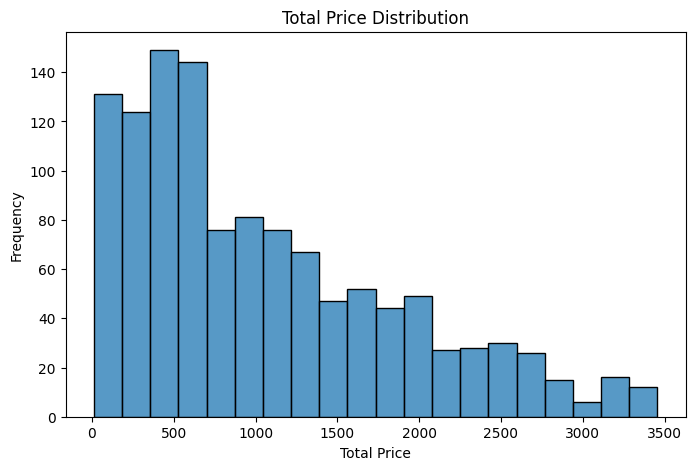

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['TotalPrice'],
    bins=20
)

plt.title('Total Price Distribution')
plt.xlabel('Total Price')
plt.ylabel('Frequency')

plt.show()